In [3]:
from helper_functions_MTL import build_dataloaders, build_model, train_model, plot_history, evaluate_model

# Alpha = 0.3

Epoch 1/30 | Train: 35.69% | Val: 47.97% | LR: 0.000100
Epoch 2/30 | Train: 46.66% | Val: 50.68% | LR: 0.000100
Epoch 3/30 | Train: 50.76% | Val: 53.25% | LR: 0.000100
Epoch 4/30 | Train: 55.30% | Val: 55.69% | LR: 0.000100
Epoch 5/30 | Train: 58.93% | Val: 50.68% | LR: 0.000100
Epoch 6/30 | Train: 61.58% | Val: 54.20% | LR: 0.000100
Epoch 7/30 | Train: 65.11% | Val: 55.83% | LR: 0.000100
Epoch 8/30 | Train: 67.28% | Val: 53.25% | LR: 0.000100
Epoch 9/30 | Train: 70.25% | Val: 51.49% | LR: 0.000100
Epoch 10/30 | Train: 73.72% | Val: 58.81% | LR: 0.000100
Epoch 11/30 | Train: 76.13% | Val: 60.03% | LR: 0.000100
Epoch 12/30 | Train: 79.03% | Val: 59.21% | LR: 0.000100
Epoch 13/30 | Train: 81.46% | Val: 52.98% | LR: 0.000100
Epoch 14/30 | Train: 84.02% | Val: 56.37% | LR: 0.000050
Epoch 15/30 | Train: 88.78% | Val: 60.03% | LR: 0.000050
Epoch 16/30 | Train: 91.19% | Val: 58.81% | LR: 0.000050
Epoch 17/30 | Train: 92.56% | Val: 60.84% | LR: 0.000050
Epoch 18/30 | Train: 93.33% | Val: 59.08

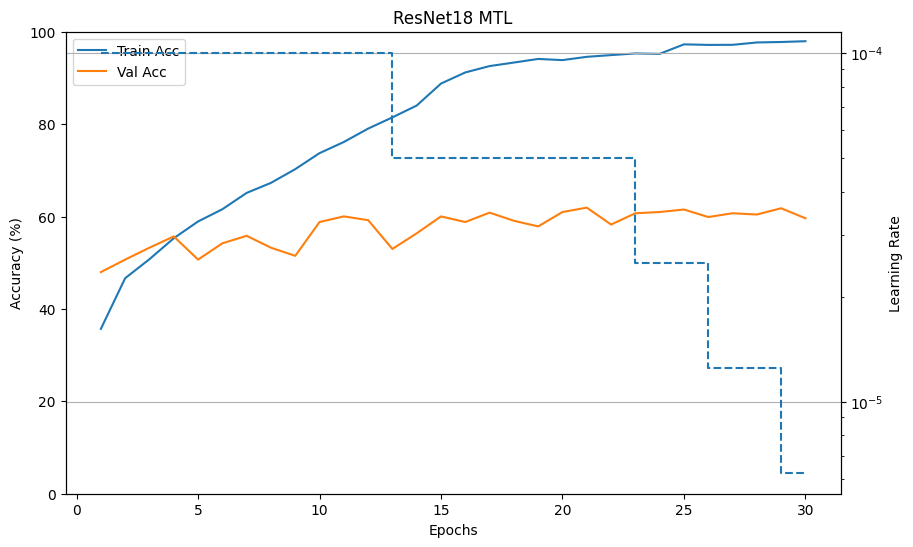


Final Test Accuracy: 67.57%


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=30,
    alpha=0.3
)

plot_history(history, "ResNet18 MTL")

test_accuracy = evaluate_model(model, test_loader)

# Confusion Matrix Plotting


In [1]:
from helper_functions_MTL import build_dataloaders, build_model, train_model, plot_confusion_matrix, evaluate_model

Epoch 1/30 | Train: 35.20% | Val: 42.55% | LR: 0.000100
Epoch 2/30 | Train: 44.75% | Val: 46.88% | LR: 0.000100
Epoch 3/30 | Train: 50.37% | Val: 53.39% | LR: 0.000100
Epoch 4/30 | Train: 54.16% | Val: 55.01% | LR: 0.000100
Epoch 5/30 | Train: 57.64% | Val: 53.39% | LR: 0.000100
Epoch 6/30 | Train: 60.24% | Val: 51.76% | LR: 0.000100
Epoch 7/30 | Train: 64.72% | Val: 54.20% | LR: 0.000050
Epoch 8/30 | Train: 71.60% | Val: 58.27% | LR: 0.000050
Epoch 9/30 | Train: 74.87% | Val: 56.91% | LR: 0.000050
Epoch 10/30 | Train: 76.52% | Val: 60.57% | LR: 0.000050
Epoch 11/30 | Train: 79.75% | Val: 57.59% | LR: 0.000050
Epoch 12/30 | Train: 81.38% | Val: 58.40% | LR: 0.000050
Epoch 13/30 | Train: 83.53% | Val: 59.49% | LR: 0.000025
Epoch 14/30 | Train: 87.72% | Val: 58.40% | LR: 0.000025
Epoch 15/30 | Train: 89.13% | Val: 58.27% | LR: 0.000025
Epoch 16/30 | Train: 90.14% | Val: 59.08% | LR: 0.000013
Epoch 17/30 | Train: 91.92% | Val: 57.86% | LR: 0.000013
Epoch 18/30 | Train: 92.87% | Val: 59.08

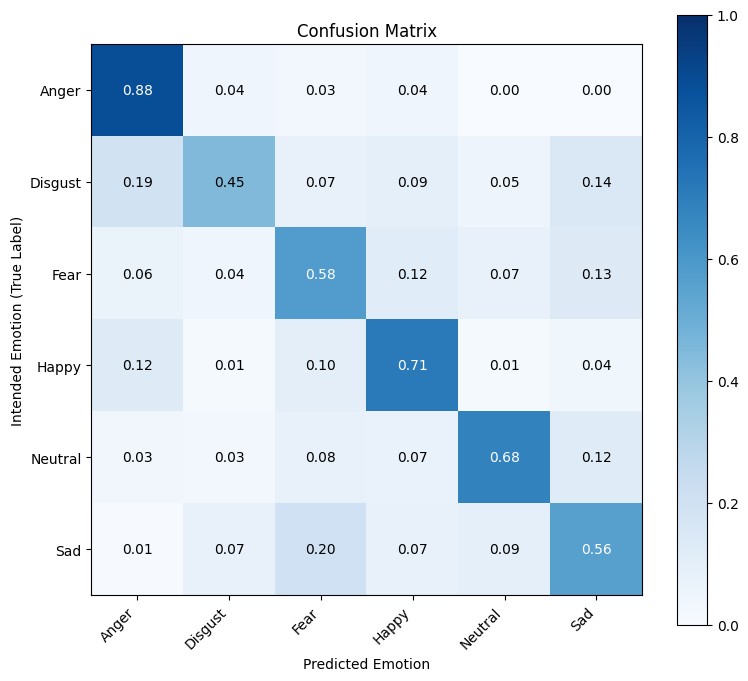

array([[0.88489209, 0.04316547, 0.02877698, 0.04316547, 0.        ,
        0.        ],
       [0.1942446 , 0.44604317, 0.07194245, 0.09352518, 0.05035971,
        0.14388489],
       [0.0647482 , 0.04316547, 0.57553957, 0.11510791, 0.07194245,
        0.1294964 ],
       [0.12230216, 0.01438849, 0.10071942, 0.71223022, 0.01438849,
        0.03597122],
       [0.03361345, 0.02521008, 0.07563025, 0.06722689, 0.68067227,
        0.11764706],
       [0.00719424, 0.07194245, 0.20143885, 0.07194245, 0.08633094,
        0.56115108]])

In [5]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=30,
    alpha=0.3
)

test_accuracy = evaluate_model(model, test_loader)

plot_confusion_matrix(model, test_loader)